In [124]:
using Revise
includet("../../cluster_env/runs/si_disprel2/base.jl")

In [125]:
using ProgressMeter
using ColorSchemes
using UnPack

In [126]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Loading all the runs into one dataframe and set DN

In [127]:
maindir = "../../cluster_env/runs/si_disprel2/main1/"

files = filter(readdir(maindir; join=true)) do f
    endswith(f, ".jld2") && !endswith(f, "_fit.jld2")
end
sort!(files; by=f -> parse(Int, match(r"gi(\d+)", basename(f))[1]))

adf = mapreduce(vcat, files) do fname
    metadata, df = load(fname, "metadata", "df")
    insertcols!(df, 1,
        :file => basename(fname),
        :row_id => 1:nrow(df),
        :K => metadata.K,
        :l => metadata.l,
        :p => metadata.p,
    )
end

adf.hss_mrl = map(eachrow(adf)) do r
    M1 = Matrix{Float64}(undef, sum(get_Ns(r.params)), sum(get_Ns(r.params)))
    make_M1!(M1, r.params, r.final_states)
    maximum(real, eigvals!(M1))
end

@show nrow(adf) length(files);

nrow(adf) = 1500
length(files) = 60

In [128]:
# Filter for good data only
keep_row = map(eachrow(adf)) do r
    (r.retcodes == ReturnCode.Success) &&
    (r.maxresids < 1e-5) &&
    (r.hss_mrl < 1e-9) &&
    (r.num_surv > 0)
end
@show count(keep_row), nrow(adf)
adf = adf[keep_row, :];

(count(keep_row), nrow(adf)) = (1282, 1500)

In [129]:
DN = 1e-12
for r in eachrow(adf)
    N = get_Ns(r.params)[1]
    r.Dss[1:N] .= DN
end

# Do the fitting and filtering

In [130]:
ks = 10 .^ range(-5, 4.5, 1000)
kweight = 0.01
# kweight = 100.

# fit_mm_d itself returns nothing when the SI system is not spatially unstable
fits = Vector{Any}(undef, nrow(adf))
prog = Progress(nrow(adf))
@tasks for i in 1:nrow(adf)
    r = adf[i, :]
    fits[i] = if (r.retcodes == ReturnCode.Success) && (r.num_surv != 0)
        fit_mm_d(r.params, r.final_states, r.Dss, r.K, r.l, r.p, ks, kweight; DN)
    end
    next!(prog)
end
finish!(prog)

for c in (:fit_d, :si_k, :mm_k, :si_h, :mm_h, :si_mrls, :mmls)
    adf[!, c] = [isnothing(f) ? missing : getproperty(f, c) for f in fits]
end

@show count(ismissing, adf.fit_d)

# Filter for spatially unstable rows only
keep_rows = map(eachrow(adf)) do r
    (!ismissing(r.fit_d)) &&
    (r.fit_d < 100.) &&
    (r.mm_h > 0.)
end
adf = adf[keep_rows,:];

Progress: 100%|█████████████████████████████████████████| Time: 0:00:15

count(ismissing, adf.fit_d) = 494

# Peak fitting stats

In [15]:
adf.deltak = log10.(adf.mm_k ./ adf.si_k)
adf.deltah = log10.(adf.mm_h ./ adf.si_h);

In [16]:
count(>(1e-3), abs.(adf.deltah))

4

(count(.!(inliers)), length(inliers)) = (0, 775)

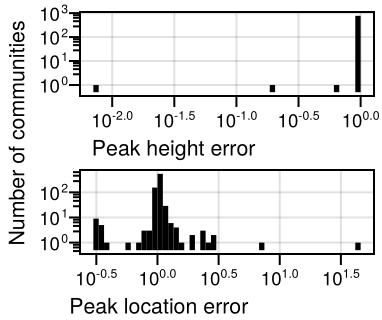

In [138]:
kcut, hcut = Inf, Inf

deltak = log10.(adf.mm_k ./ adf.si_k)
deltah = log10.(adf.mm_h ./ adf.si_h)

inliers = (abs.(deltak) .<= kcut) .& (abs.(deltah) .<= hcut)
@show count(.!inliers), length(inliers)
deltak, deltah = deltak[inliers], deltah[inliers]

fig = Figure(;
    size=(double_col_width * 0.28, 0.38 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 6.),
)
tickvals = -2.5:0.5:1.5
ax_kwargs = (;
    yscale=log10,
    xlabelsize=8fontsize_pt,
    xlabelpadding=2.,
    xticks=(tickvals, [rich("10", superscript(string(e))) for e in tickvals]),
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
)
ax1 = Axis(fig[1, 1];
    xlabel="Peak height error                  ",
    ax_kwargs...,
)
ax2 = Axis(fig[2, 1];
    xlabel="Peak location error                       ",
    ax_kwargs...,
)
hist!(ax1, deltah;
    bins=50,
    color=:black,
)
hist!(ax2, deltak;
    bins=50,
    color=:black,
)
Label(fig[:,0], "Number of communities";
    fontsize=8fontsize_pt,
    rotation=pi/2,
)

rowgap!(fig.layout, 6.)
colgap!(fig.layout, 6.)

Makie.save("../../figures2/fig2/fit_metrics.pdf", fig)

fig

# Example disprel fits

In [131]:
"""
    symlog10(linthresh)

Symlog-style Makie scale: linear inside `±linthresh`, log10 outside, joined
smoothly as `y -> sign(y) * log10(1 + |y|/linthresh)`. Every factor of 10 above
`linthresh` gets one unit of axis space, so both signs and many decades of
magnitude fit on one axis. Pair with `symlog10_ticks`/`symlog10_minorticks`
(or just use `symlog10_kwargs`) - Makie's automatic ticks fall back to linearly
spaced values for any non-log scale, which is what makes a bare symlog axis
look wrong.
"""
function symlog10(linthresh)
    t = float(linthresh)
    t > 0. || throw(ArgumentError("linthresh must be positive"))
    forward = y -> sign(y) * log10(1. + abs(y)/t)
    inverse = z -> sign(z) * t * (exp10(abs(z)) - 1.)
    Makie.ReversibleScale(forward, inverse; limits=(-3f0, 3f0), name=:symlog10)
end

function symlog10_ticklabel(v)
    v == 0. && return rich("0")
    e = round(Int, log10(abs(v)))
    sgn = v < 0. ? Makie.MINUS_SIGN : ""
    rich(sgn * "10", superscript(replace(string(e), "-" => Makie.MINUS_SIGN);
        offset=Vec2f(0.1, 0.)))
end

"""
    symlog10_ticks(linthresh; max_ticks=11)

Ticks at 0 and ±10^n from `linthresh` up, thinned to at most `max_ticks`.
"""
function symlog10_ticks(linthresh; max_ticks=11)
    e0 = round(Int, log10(float(linthresh)))
    (vmin, vmax) -> begin
        hi = max(abs(vmin), abs(vmax))
        emax = max(hi > 0. ? floor(Int, log10(hi)) : e0, e0)
        estep = max(1, cld(2*(emax - e0 + 1) + 1, max_ticks))
        vals = [0.]
        for e in e0:estep:emax
            push!(vals, 10.0^e, -10.0^e)
        end
        sort!(vals)
        filter!(v -> vmin <= v <= vmax, vals)
        vals, symlog10_ticklabel.(vals)
    end
end

"""
    symlog10_minorticks(linthresh; ndecades=12)

Minor ticks at ±(2:9)·10^n over `ndecades` decades starting at `linthresh`.
"""
function symlog10_minorticks(linthresh; ndecades=12)
    e0 = round(Int, log10(float(linthresh)))
    vals = Float64[]
    for e in e0:(e0 + ndecades), m in 2:9
        push!(vals, m * 10.0^e, -m * 10.0^e)
    end
    sort!(vals)
end

"""
    symlog10_linthresh(vals...; floor_frac=1e-6)

Pick a linthresh for `vals`: the nearest decade to the smallest nonzero magnitude,
but never more than `floor_frac` below the largest one.
"""
function symlog10_linthresh(vals...; floor_frac=1e-6)
    as = filter(>(0.), abs.(reduce(vcat, map(collect, vals))))
    isempty(as) && return 1.
    10.0^round(Int, log10(max(minimum(as), floor_frac * maximum(as))))
end

"""
    symlog10_kwargs(linthresh; dim=:y, kwargs...)

All the `Axis` kwargs needed for a symlog `dim` axis at once, e.g.
`Axis(fig[1,1]; symlog10_kwargs(1e-6)...)`.
"""
function symlog10_kwargs(linthresh; dim=:y, max_ticks=11, ndecades=12, minorgrid=false)
    kwargs = (;
        scale=symlog10(linthresh),
        ticks=symlog10_ticks(linthresh; max_ticks),
        minorticks=symlog10_minorticks(linthresh; ndecades),
        minorticksvisible=true,
        minorgridvisible=minorgrid,
    )
    NamedTuple(Symbol(dim, k) => v for (k, v) in pairs(kwargs)) # prefix each key with dim
end


symlog10_kwargs

In [148]:
seed = 46
example_is = sort(randperm(Xoshiro(seed), nrow(adf))[1:4])

4-element Vector{Int64}:
  86
 298
 640
 762

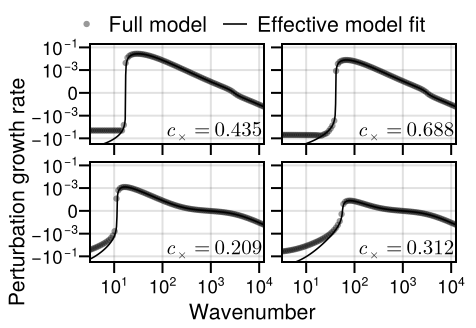

In [157]:
ydepth = 3. # decades of log range below the tallest peak - this sets linthresh
yup = 4.3   # top of the axis, in decades above linthresh
ydown = 4.5 # bottom of the axis, in decades below -linthresh

# the SI disprel is sampled on all 1000 ks, which is far denser than the panel can
# resolve as markers - show every sistride'th one
sistride = 4
si_kwargs = (; color=(:black, 0.4), markersize=4.5)
mm_kwargs = (; color=:black, linewidth=0.8)

function trimmed_symlog10_ticks(linthresh; kwargs...)
    base = symlog10_ticks(linthresh; kwargs...)
    (vmin, vmax) -> begin
        vals, labels = base(vmin, vmax)
        keep = map(v -> (v == 0.) || (abs(v) > 10linthresh), vals)
        vals[keep], labels[keep]
    end
end

function decade_symlog10_minorticks(linthresh; ndecades=12, mantissas=(1., 2., 5.))
    e0 = round(Int, log10(float(linthresh)))
    sort!([s * m * 10.0^e for e in e0:(e0 + ndecades) for m in mantissas for s in (1., -1.)])
end

# one y scale shared by all four panels, anchored on the tallest peak of the four,
# so peak heights can be compared across panels
peak = maximum(example_is) do i
    max(maximum(adf[i, :si_mrls]), maximum(adf[i, :mmls]))
end
linthresh = 10. ^ (floor(log10(peak)) - ydepth)

fig = Figure(;
    # size=(double_col_width * 0.48, 0.55 * double_col_width / golden_ratio),
    size=(double_col_width * 0.35, 0.39 * double_col_width / golden_ratio),
    figure_padding=(2., 10., 2., 6.),
)

axs = Axis[]
for (n, i) in enumerate(example_is)
    r = adf[i, :]
    row, col = fldmod1(n, 2)

    kks, si_mrls, mmls = ks, r.si_mrls, r.mmls

    ax = Axis(fig[row, col];
        xscale=log10,
        symlog10_kwargs(linthresh; max_ticks=5)...,
        yticks=trimmed_symlog10_ticks(linthresh; max_ticks=6),
        yminorticksvisible=false, # symlog10_kwargs turns these on
        xticks=log10ticks(0:5),
        xticklabelsize=7fontsize_pt,
        yticklabelsize=7fontsize_pt,
        xticklabelpad=0.,
        yticklabelpad=0.,
        # xgridvisible=false,
        # ygridvisible=false,
    )

    # hlines!(ax, [0.]; color=:gray, linewidth=0.5)
    # hlines!(ax, [-linthresh, linthresh];
    #     color=:gray,
    #     linestyle=:dash,
    #     linewidth=0.5,
    # )
    scatter!(ax, kks[1:sistride:end], si_mrls[1:sistride:end]; si_kwargs...)
    lines!(ax, kks, mmls; mm_kwargs...)

    text!(ax, 0.99, 0.01;
        text=latexstring(@sprintf "c_\\times=%.3g" r.fit_d),
        space=:relative,
        align=(:right, :bottom),
        justification=:right,
        fontsize=7fontsize_ltex_pt,
    )

    # xlims!(ax, extrema(kks)...)
    xlims!(ax, 10^0.5, 10^4.1)
    ylims!(ax, -linthresh * 10^ydown, linthresh * 10^yup)

    # both scales are shared, so only label each one once
    col == 2 && hideydecorations!(ax; ticks=false, grid=false)
    row == 1 && hidexdecorations!(ax; ticks=false, grid=false)
    push!(axs, ax)
end
linkaxes!(axs...)

Label(fig[1:2, 0], "Perturbation growth rate             ";
    fontsize=8fontsize_pt,
    rotation=pi/2,
    padding=(0., 2., 0., 0.),
)
Label(fig[3, 1:2], "Wavenumber       ";
    fontsize=8fontsize_pt,
    padding=(0., 0., 0., 2.),
)
Legend(fig[0, 0:2],
    [MarkerElement(; marker=:circle, si_kwargs...), LineElement(; mm_kwargs...)],
    ["Full model", "Effective model fit"];
    orientation=:horizontal,
    labelsize=8fontsize_pt,
    framevisible=false,
    padding=(20., 0., 0., 0.),
    patchsize=(12., 6.),
    colgap=8.,
)

rowgap!(fig.layout, 4.)
colgap!(fig.layout, 4.)
colgap!(fig.layout, 1, 0.)
rowgap!(fig.layout, 1, 4.) # legend to panels
rowgap!(fig.layout, 3, 0.) # panels to x label

Makie.save("../../figures2/fig2/disprel_examples.pdf", fig)

fig


# Debugging weird rows

In [384]:
sdf = adf[findall(abs.(rel_h_error) .> 1e-5),:];
sort(collect(zip(sdf.si_h, sdf.mm_h)); by=x->sum(x))

117-element Vector{Tuple{Float64, Float64}}:
 (-1.0395291039352393e-8, -2.399999095108154e-7)
 (-1.6506625658556661e-9, -2.3999990951081547e-7)
 (4.5328150199894206e-9, -2.399999095108154e-7)
 (7.967537786465685e-9, -2.399999095108154e-7)
 (8.717917626713685e-9, -2.399999095108154e-7)
 (9.195560533824627e-9, -2.399999095108154e-7)
 (9.29344528956254e-9, -2.3999990951081547e-7)
 (1.334420090128526e-8, -2.399999095108154e-7)
 (3.6747364426982503e-9, -1.794763925668187e-7)
 (5.4744033915958444e-9, -1.794763925668187e-7)
 (1.6250846592106779e-10, -1.7257408427153802e-7)
 (8.908605631573284e-9, -1.7947639256681876e-7)
 (1.1089237070278537e-8, -1.7947639256681873e-7)
 ⋮
 (0.00011002192071614823, 6.96955116558668e-5)
 (0.00044811894766301545, -1.7947639256681884e-7)
 (0.0006503408206517541, -2.399999095108298e-7)
 (0.0007342634562552792, -6.579057631597936e-8)
 (0.0016656723925933324, -2.278463079681127e-18)
 (0.0016963820769934253, 0.0003247279669398813)
 (0.0020691411103137204, -2.588043864

(r.K, r.l, r.p) = (100.0, 0.99, 1.0)
r.fit_d = 0.010255415080695558
hss = [98.82456140350877, 1.0017574692442883, 0.17368112724693988]

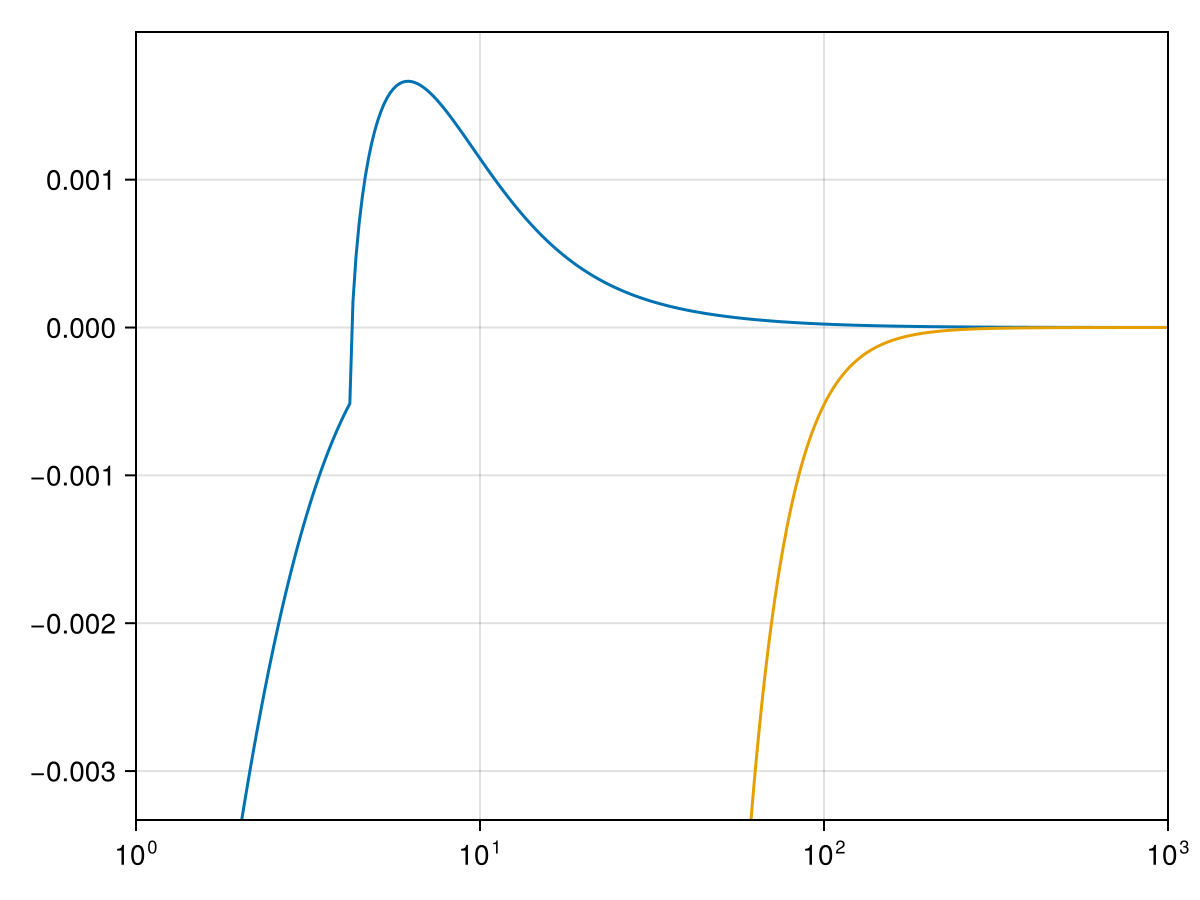

In [593]:
r = sdf[end-10,:]
@show r.K, r.l, r.p
@show r.fit_d

fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
)

d = r.fit_d
d = 5.7
mmp = MMParams(; K=r.K, l=r.l, m=1., c=1., d=d)
hss = mmv3_get_hss_unique(mmp)
@show hss
mmls = fr3_disprel_simple(mmp, 0., 1., r.p, hss[1], ks)

lines!(ax, ks, r.si_mrls)
lines!(ax, ks, mmls)

mm = abs(max(maximum(r.si_mrls), maximum(mmls)))
ylims!(ax, (-2., 1.2) .* mm)
xlims!(ax, 1e0, 1e3)

# display(GLMakie.Screen(), fig)

fig

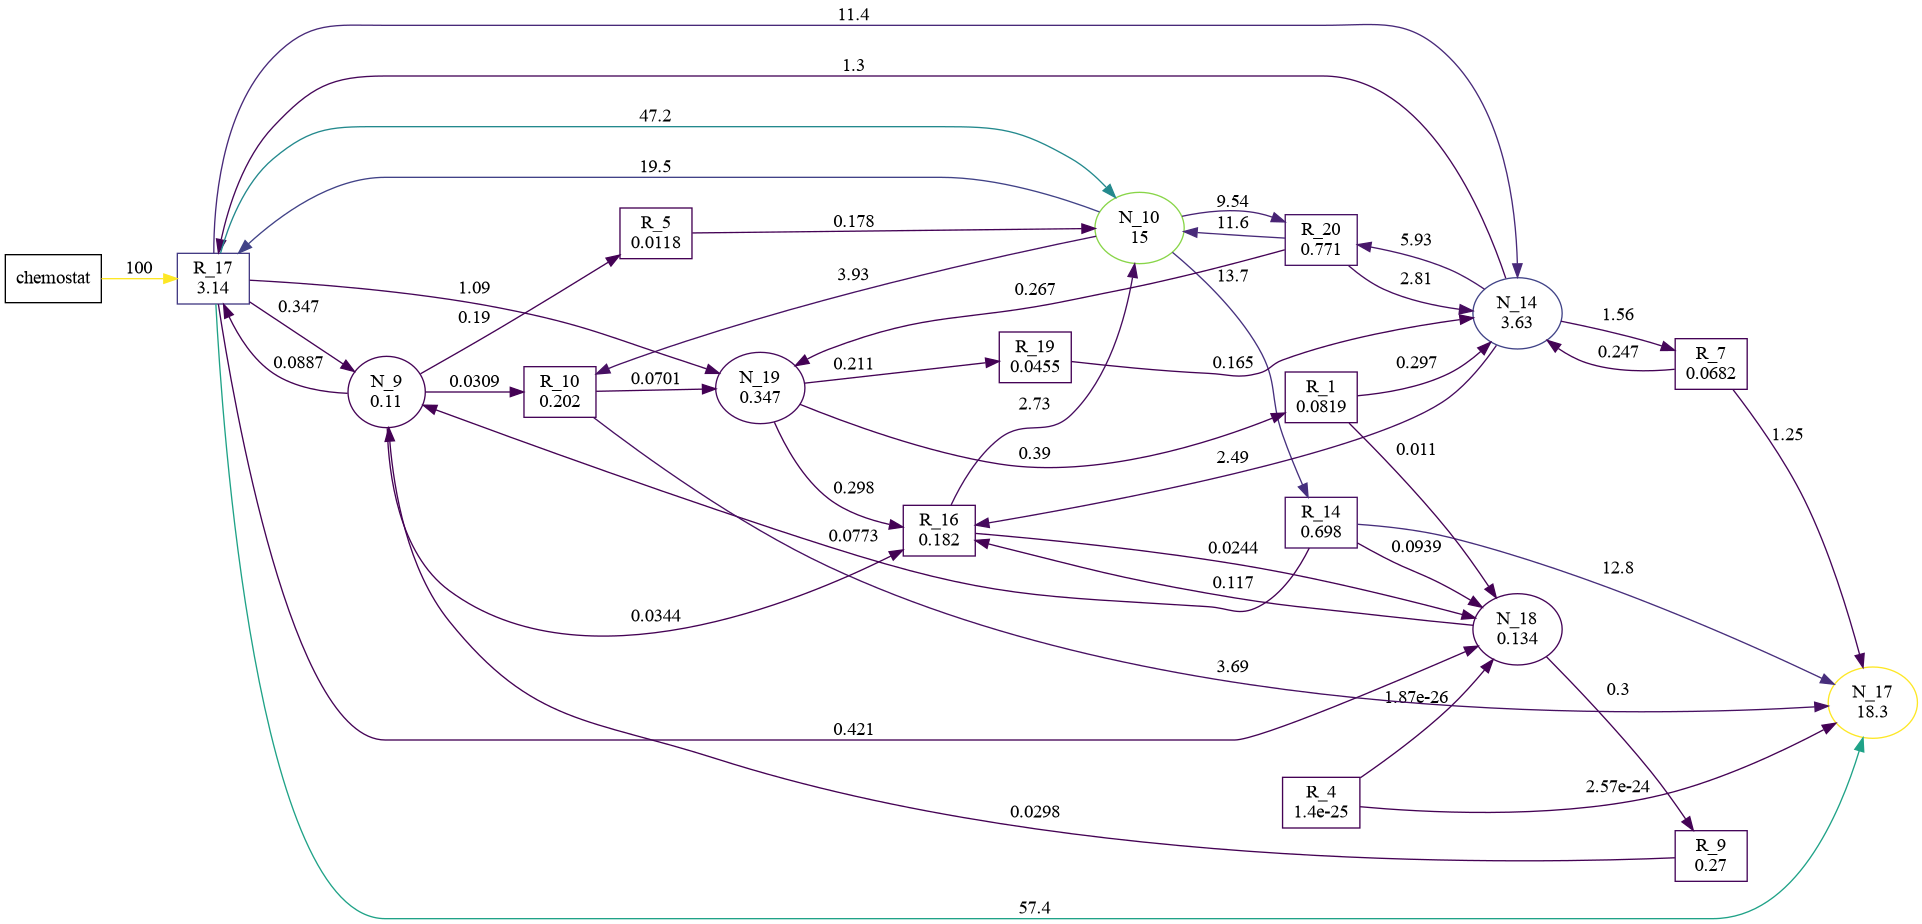

In [594]:
diagram_sfss_v3(r.params, r.final_states;
    strain_threshold=1e-1,
)